In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

# Direct QA

In [3]:
prompt_type = "direct_qa"

In [ ]:
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration/summary.csv"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")

In [ ]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df = pd.DataFrame(all_records_direct).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

dataset_weighted_average_mean = (
    df.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

dataset_weighted_average_mean

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean,calibrated_su_beta_guided_lc_generalised_ECE,calibrated_su_beta_guided_lc_faithfulness_divergence,calibrated_su_beta_guided_lc_ece_mean,calibrated_su_beta_guided_lc_dAUROC,calibrated_su_beta_guided_lc_auroc_mean
0,GPT-OSS-20B,0.277496,1.472587,0.235994,0.508565,0.505802,0.215273,1.377133,0.189932,0.564103,...,0.114516,0.704376,0.103600,0.670591,0.696067,0.173183,0.745216,0.151057,0.570133,0.590750
1,Llama-3.1-8B-Inst.,0.251591,1.280265,0.210116,0.534427,0.543703,0.220941,2.943417,0.209530,0.651293,...,0.108025,0.571482,0.088026,0.639382,0.678086,0.141983,0.713628,0.131070,0.564332,0.594440
2,Mistral-7B-Inst.,0.298302,1.610928,0.271704,0.506678,0.503897,0.331278,159.977665,0.329564,0.630860,...,0.114870,0.576941,0.096068,0.540853,0.553150,0.181772,0.797122,0.178489,0.517141,0.524826
3,Qwen3-8B-Inst.,0.274596,1.538303,0.227096,0.533431,0.541527,0.372578,204.820376,0.370441,0.576911,...,0.161632,0.750108,0.144814,0.560921,0.583592,0.178500,0.795816,0.165379,0.524709,0.536517


In [6]:
# calibrated beta guided FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_faithfulness_divergence", "calibrated_tp_beta_guided_lc_faithfulness_divergence", "calibrated_su_beta_guided_lc_faithfulness_divergence"]].mean()

np.float64(0.7864477099771289)

In [7]:
# calibrated beta guided ECE 
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_generalised_ECE", "calibrated_tp_beta_guided_lc_generalised_ECE", "calibrated_su_beta_guided_lc_generalised_ECE"]].mean()

np.float64(0.17527898520316906)

In [8]:
# calibrated FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean()

np.float64(0.7052425354568822)

In [9]:
# calibrated ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean()

np.float64(0.14638599257359516)

In [10]:
# original FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"]

np.float64(1.4755207557320844)

In [11]:
# original ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"]

np.float64(0.2754962259819099)

# Hedged QA

In [15]:
prompt_type = "hedged_qa"

In [ ]:
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration/summary.csv"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_hedged = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_hedged.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_hedged = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_hedged.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")

In [17]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df_hedged = pd.DataFrame(all_records_hedged).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df_hedged.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

hedged_dataset_weighted_average_mean = (
    df_hedged.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

hedged_dataset_weighted_average_mean

KeyError: "['dataset'] not found in axis"

# Plot

ValueError: 'yerr' (shape: (3,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (4,))

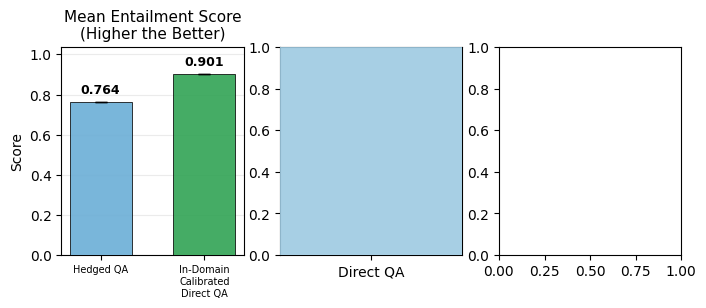

In [ ]:
import matplotlib.pyplot as plt

# Values taken from the summary above
entailment_scores = {
    "Hedged QA": 0.764,
    "In-Domain\nCalibrated\nDirect QA": 0.901,
}

faithfulness_divergence = {
    "Direct QA\n(Original)": dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"],
    "Hedged QA\n(Black-box Baseline)": 1.7749233048565647,
    "Direct QA\n(Direct Beta-Guided Rewrite)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_faithfulness_divergence", "calibrated_tp_beta_guided_lc_faithfulness_divergence", "calibrated_su_beta_guided_lc_faithfulness_divergence"]].mean(),
    "Direct QA\n(Retrieval-Augmented Rewrite)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean(),
}

generalised_ece = {
    "Direct QA\n(Original)": dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"],
    "Hedged QA\n(Hedged QA)": 0.272770214125857,
    "Direct QA\n(Direct Beta-Guided Rewrite)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_generalised_ECE", "calibrated_tp_beta_guided_lc_generalised_ECE", "calibrated_su_beta_guided_lc_generalised_ECE"]].mean(),
    "Direct QA\n(Retrieval-Augmented Rewrite)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean(),
}

fig, axes = plt.subplots(1, 3, figsize=(8, 2.7))

def annotate_bars(ax, bars, decimals=3):
    heights = [bar.get_height() for bar in bars]
    y_max = max(heights) if heights else 0
    y_offset = max(y_max * 0.03, 0.012)

    # Increase y-axis headroom so value labels stay within the subplot.
    current_bottom, current_top = ax.get_ylim()
    target_top = y_max + y_offset * 5.0
    if target_top > current_top:
        ax.set_ylim(current_bottom, target_top)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            f"{h:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            clip_on=True,
        )

# LEFT: Mean entailment score (Hedged QA vs In-Domain Calibrated Direct QA)
bars0 = axes[0].bar(
    list(entailment_scores.keys()),
    list(entailment_scores.values()),
    color=["#6BAED6", "#31A354"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    width=0.6,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0],
)
axes[0].set_title("Mean Entailment Score\n(Higher the Better)", fontsize=11)
axes[0].set_ylabel("Score", fontsize=10)
axes[0].grid(axis="y", alpha=0.25, zorder=0)
axes[0].tick_params(axis="x", labelsize=7)
annotate_bars(axes[0], bars0, decimals=3)

# MIDDLE: Mean faithfulness divergence (three QAs)
bars1 = axes[1].bar(
    list(faithfulness_divergence.keys()),
    list(faithfulness_divergence.values()),
    color=["#9ECAE1", "#6BAED6", "#31A354"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    width=0.6,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0],
)
axes[1].set_title("Mean Faithfulness Divergence\n(Lower the Better)", fontsize=11)
axes[1].set_ylabel("Faithfulness Divergence", fontsize=10)
axes[1].grid(axis="y", alpha=0.25, zorder=0)
axes[1].tick_params(axis="x", labelsize=7)
annotate_bars(axes[1], bars1, decimals=3)

# RIGHT: Mean generalised ECE (three QAs)
bars2 = axes[2].bar(
    list(generalised_ece.keys()),
    list(generalised_ece.values()),
    color=["#9ECAE1", "#6BAED6", "#31A354"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    width=0.6,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0],
)
axes[2].set_title("Mean Generalised ECE\n(Lower the Better)", fontsize=11)
axes[2].set_ylabel("Generalised ECE", fontsize=10)
axes[2].grid(axis="y", alpha=0.25, zorder=0)
axes[2].tick_params(axis="x", labelsize=7)
annotate_bars(axes[2], bars2, decimals=3)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")

fig.tight_layout()
plt.savefig("pipeline_vs_hedged_qa_baseline_calibration.pdf", dpi=300, bbox_inches="tight")